# Day 21: Build a CNN from Scratch — Complete Project

> **Goal:** Design, train, evaluate, and debug a CNN from scratch. Apply every technique you've learned.

---

## Project: High-Accuracy CIFAR-10 Classifier

Today we bring everything together:
- Thoughtful architecture design
- Data augmentation
- BatchNorm, Dropout, Weight Decay
- LR scheduling
- Checkpointing & early stopping
- Comprehensive evaluation

**Target: >90% test accuracy on CIFAR-10 with a model you designed yourself.**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## 1. Data Pipeline

In [2]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Stronger augmentation for better generalization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.1),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_data  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
train_data, val_data = random_split(full_train, [45000, 5000], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_data,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)

classes = full_train.classes
print(f"Dataset: {len(train_data)} train, {len(val_data)} val, {len(test_data)} test")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Dataset: 45000 train, 5000 val, 10000 test
Train batches: 352, Val batches: 20, Test batches: 40


---
## 2. Model Architecture

We'll build a ResNet-style model with:
- Residual blocks
- BatchNorm everywhere
- Global average pooling
- Dropout before FC

In [3]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU."""
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ResBlock(nn.Module):
    """Residual block with skip connection."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return torch.relu(out + identity)


class MyCNN(nn.Module):
    """Custom CNN for CIFAR-10."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Stage 1: 3 → 64, 32×32
            ConvBlock(3, 64),
            ResBlock(64),
            nn.MaxPool2d(2),         # → 16×16

            # Stage 2: 64 → 128, 16×16
            ConvBlock(64, 128),
            ResBlock(128),
            nn.MaxPool2d(2),         # → 8×8

            # Stage 3: 128 → 256, 8×8
            ConvBlock(128, 256),
            ResBlock(256),
            nn.MaxPool2d(2),         # → 4×4

            # Stage 4: 256 → 512, 4×4
            ConvBlock(256, 512),
            ResBlock(512),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x


model = MyCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

MyCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-0

---
## 3. Training Pipeline

In [4]:
# Hyperparameters
config = {
    "epochs": 50,
    "lr": 1e-3,
    "weight_decay": 5e-4,
    "patience": 10,
}

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

### Run Training with Checkpointing & Early Stopping

The loop below combines every technique we've learned:
- **Checkpointing** — saves the model whenever validation accuracy improves (so we keep the best version)
- **Early stopping** — if val accuracy doesn't improve for `patience` epochs, we stop to avoid wasting time
- **LR scheduling** — cosine annealing smoothly decreases the learning rate

The `✓` marker in the output indicates epochs where a new best model was saved.

In [5]:
# Training loop with checkpointing
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val_acc = 0
epochs_no_improve = 0

print(f"{'Ep':>3} | {'TrLoss':>7} | {'TrAcc':>6} | {'VLoss':>7} | {'VAcc':>6} | {'LR':>9} | {'Time':>5}")
print("-" * 60)

for epoch in range(config["epochs"]):
    t0 = time.time()
    tl, ta = train_one_epoch(model, train_loader, loss_fn, optimizer)
    vl, va = evaluate(model, val_loader)
    lr_now = optimizer.param_groups[0]["lr"]
    scheduler.step()
    elapsed = time.time() - t0

    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta); history["val_acc"].append(va)
    history["lr"].append(lr_now)

    marker = ""
    if va > best_val_acc:
        best_val_acc = va
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_cnn.pt")
        marker = " ✓"
    else:
        epochs_no_improve += 1

    if (epoch+1) % 5 == 0 or epoch == 0 or marker:
        print(f"{epoch+1:3d} | {tl:7.4f} | {ta:5.1%} | {vl:7.4f} | {va:5.1%} | {lr_now:9.6f} | {elapsed:4.1f}s{marker}")

    if epochs_no_improve >= config["patience"]:
        print(f"\n⏹ Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(torch.load("best_cnn.pt", map_location=device, weights_only=True))
print(f"\n✅ Best val accuracy: {best_val_acc:.2%}")

 Ep |  TrLoss |  TrAcc |   VLoss |   VAcc |        LR |  Time
------------------------------------------------------------
  1 |  1.4522 | 46.4% |  1.6993 | 47.7% |  0.001000 | 30.6s ✓
  2 |  0.9747 | 65.5% |  1.0830 | 63.6% |  0.000999 | 24.7s ✓
  3 |  0.8054 | 72.1% |  0.9432 | 66.4% |  0.000996 | 24.7s ✓
  4 |  0.7097 | 75.6% |  0.7636 | 73.4% |  0.000991 | 24.6s ✓
  5 |  0.6440 | 78.0% |  0.7747 | 73.2% |  0.000984 | 24.7s
  6 |  0.5956 | 79.9% |  0.6882 | 76.4% |  0.000976 | 24.7s ✓
  7 |  0.5559 | 81.1% |  0.6953 | 76.5% |  0.000965 | 24.6s ✓
  9 |  0.4865 | 83.6% |  0.6205 | 79.0% |  0.000938 | 24.9s ✓
 10 |  0.4618 | 84.4% |  0.5567 | 80.8% |  0.000922 | 25.8s ✓
 11 |  0.4378 | 85.3% |  0.5456 | 81.2% |  0.000905 | 27.9s ✓
 12 |  0.4196 | 86.0% |  0.5236 | 82.3% |  0.000885 | 29.2s ✓
 13 |  0.3969 | 86.6% |  0.4798 | 83.5% |  0.000864 | 26.6s ✓
 15 |  0.3684 | 87.6% |  0.4858 | 83.2% |  0.000819 | 25.5s
 17 |  0.3335 | 88.6% |  0.4221 | 86.2% |  0.000768 | 24.7s ✓
 18 |  0.3205

### Visualize Training History

Three plots to diagnose training behaviour:
- **Loss** — should decrease; if val loss increases while train loss decreases → overfitting
- **Accuracy** — the metric we care about; val accuracy should plateau, not diverge from train
- **Learning Rate** — shows the cosine annealing schedule; lower LR at the end helps fine-tune

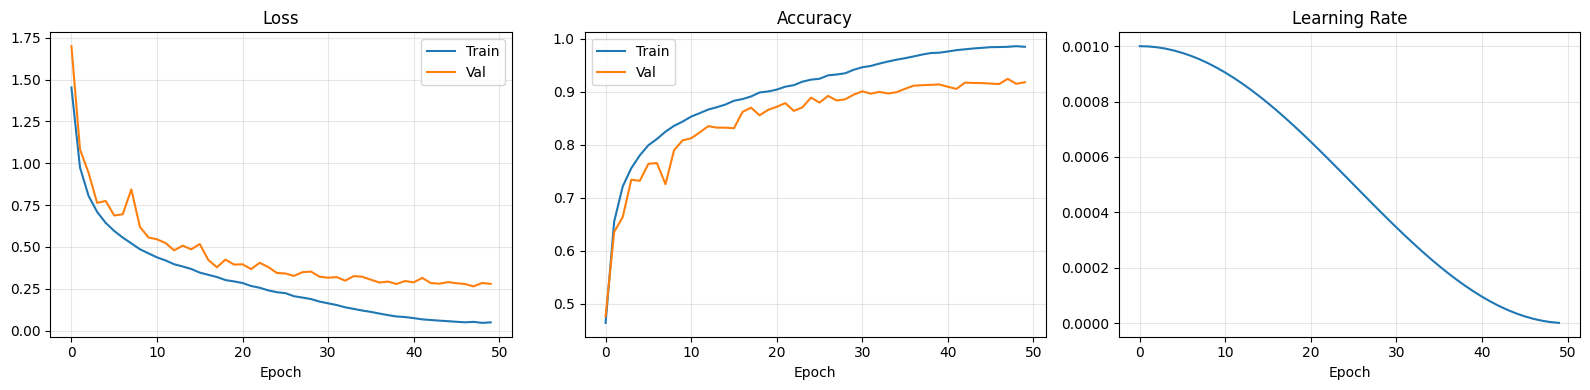

In [6]:
# Plot comprehensive training history
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history["lr"])
axes[2].set_title("Learning Rate"); axes[2].grid(True, alpha=0.3)

for ax in axes: ax.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

### Final Test Evaluation & Per-Class Analysis

Now we evaluate on the held-out test set using the **best model** (loaded from checkpoint). The classification report shows precision, recall, and F1-score for each class — this tells you which classes the model finds easiest and hardest to distinguish.

In [7]:
# Final test evaluation
test_loss, test_acc = evaluate(model, test_loader)
print(f"🎯 Final Test Accuracy: {test_acc:.2%}")

# Per-class accuracy
from sklearn.metrics import classification_report

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(lbls)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print("\n" + classification_report(all_labels, all_preds, target_names=classes))

🎯 Final Test Accuracy: 92.61%

              precision    recall  f1-score   support

    airplane       0.92      0.94      0.93      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.91      0.89      0.90      1000
         cat       0.88      0.84      0.86      1000
        deer       0.94      0.94      0.94      1000
         dog       0.86      0.88      0.87      1000
        frog       0.93      0.95      0.94      1000
       horse       0.95      0.95      0.95      1000
        ship       0.95      0.96      0.95      1000
       truck       0.94      0.95      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



---
## 🧪 Exercises

### Exercise 1: Ablation study
Remove one component at a time (augmentation, BN, dropout, residual connections) and measure the impact on test accuracy.

### Exercise 2: Hyperparameter sweep
Try 3 different learning rates and 3 different weight decay values (9 combos). Which works best?

### Exercise 3: Deeper model
Add more ResBlocks to each stage (2 instead of 1). Does deeper = better?

### Exercise 4: Ensemble
Train 3 models with different seeds. Average their predictions. Does the ensemble beat individual models?

In [ ]:
# Exercises: Your code here

---
## 📝 Key Takeaways

You've now built a complete deep learning project from scratch! The key skills:

1. **Design** an architecture with purpose (residual blocks, BN, GAP)
2. **Augment** data for regularization
3. **Train** with proper loop, checkpointing, early stopping
4. **Schedule** the learning rate (cosine annealing)
5. **Evaluate** thoroughly (per-class, confusion matrix)

**Tomorrow:** We enter the Transformer era — starting with self-attention, the key innovation behind modern AI!